In [1]:
# ============================================
# IPL Win Probability Predictor
# Day 8 — Hyperparameter Tuning
# Addition 3 — Optimizing XGBoost Settings
# ============================================
# GOAL: Use RandomizedSearchCV with match-level
# GroupKFold to find optimal XGBoost hyperparameters

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV,GroupKFold,train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported")

✅ All libraries imported


In [2]:
# Load model ready data
model_df = pd.read_csv("../data/model_ready_data.csv")

# Encode teams
model_df_encoded = pd.get_dummies(
    model_df, columns=['batting_team', 'bowling_team']
)

# Store match IDs for group splitting
match_ids = model_df_encoded['match_id'].values

# Features and target
X = model_df_encoded.drop(columns=['match_id', 'batting_team_won'])
y = model_df_encoded['batting_team_won']

# Match level train test split (same random_state=42 as always)
unique_matches = model_df_encoded['match_id'].unique()
train_match_ids, test_match_ids = train_test_split(
    unique_matches, test_size=0.2, random_state=42
)

train_data = model_df_encoded[model_df_encoded['match_id'].isin(train_match_ids)]
test_data  = model_df_encoded[model_df_encoded['match_id'].isin(test_match_ids)]

X_train = train_data.drop(columns=['match_id', 'batting_team_won'])
y_train = train_data['batting_team_won']
X_test  = test_data.drop(columns=['match_id', 'batting_team_won'])
y_test  = test_data['batting_team_won']

# Match IDs for training set only (needed for GroupKFold inside tuning)
train_match_id_array = train_data['match_id'].values

print("✅ Data loaded and split")
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

✅ Data loaded and split
Training rows: 66968
Testing rows:  16512


In [3]:
# Record baseline performance BEFORE tuning
# So we can compare fairly after tuning
baseline_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("BASELINE PERFORMANCE (Before Tuning)")
print("=" * 40)
print(f"n_estimators:  100 (default)")
print(f"max_depth:     6 (XGBoost default)")
print(f"learning_rate: 0.3 (XGBoost default)")
print(f"subsample:     1.0 (XGBoost default)")
print(f"\nAccuracy: {baseline_accuracy*100:.2f}%")
print("=" * 40)

BASELINE PERFORMANCE (Before Tuning)
n_estimators:  100 (default)
max_depth:     6 (XGBoost default)
learning_rate: 0.3 (XGBoost default)
subsample:     1.0 (XGBoost default)

Accuracy: 77.13%


In [4]:
# Define the hyperparameter space to search
param_distributions = {
    'n_estimators': [100, 150, 200, 250, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 5, 7, 10],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5]
}
# Count total possible combinations
total_combinations = 1
for param,values in param_distributions.items():
    total_combinations*=len(values)

print("HYPERPARAMETER SEARCH SPACE")
print("=" * 40)
for param, values in param_distributions.items():
    print(f"{param:<20}: {values}")
print("=" * 40)
print(f"\nTotal possible combinations: {total_combinations:,}")
print(f"We will randomly sample:     50")
print(f"Computation saved:           {(1 - 50/total_combinations)*100:.1f}%")

HYPERPARAMETER SEARCH SPACE
n_estimators        : [100, 150, 200, 250, 300, 400, 500]
max_depth           : [3, 4, 5, 6, 7, 8, 10]
learning_rate       : [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
subsample           : [0.6, 0.7, 0.8, 0.9, 1.0]
colsample_bytree    : [0.6, 0.7, 0.8, 0.9, 1.0]
min_child_weight    : [1, 2, 3, 5, 7, 10]
gamma               : [0, 0.1, 0.2, 0.3, 0.5]

Total possible combinations: 220,500
We will randomly sample:     50
Computation saved:           100.0%


In [5]:
# GroupKFold ensures match-level splits INSIDE the hyperparameter search too
group_kfold = GroupKFold(n_splits=5)

print("Cross validation strategy: GroupKFold")
print(f"Number of folds: 5")
print(f"Splitting level: Match-level (no group leakage)")
print(f"\nThis means RandomizedSearchCV will:")
print(f"  1. Sample 50 random hyperparameter combinations")
print(f"  2. For EACH combination, run 5-fold GroupKFold CV")
print(f"  3. Total model trainings: 50 × 5 = 250")
print(f"  4. Return the combination with best average CV accuracy")

Cross validation strategy: GroupKFold
Number of folds: 5
Splitting level: Match-level (no group leakage)

This means RandomizedSearchCV will:
  1. Sample 50 random hyperparameter combinations
  2. For EACH combination, run 5-fold GroupKFold CV
  3. Total model trainings: 50 × 5 = 250
  4. Return the combination with best average CV accuracy


In [6]:
# Base XGBoost model to tune
xgb_base=xgb.XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',verbosity=0)

# RandomizedSearchCV setup
random_search=RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,
    cv=group_kfold,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("Starting RandomizedSearchCV...")
print("Testing 50 combinations × 5 folds = 250 model trainings")
print("Estimated time: 10-20 minutes")
print("(verbose=2 will show progress below)")
print("-" * 50)

# Run the search - pass match IDs as groups
random_search.fit(X_train,y_train,groups=train_match_id_array)

print("-" * 50)
print("✅ Search complete!")

Starting RandomizedSearchCV...
Testing 50 combinations × 5 folds = 250 model trainings
Estimated time: 10-20 minutes
(verbose=2 will show progress below)
--------------------------------------------------
Fitting 5 folds for each of 50 candidates, totalling 250 fits
--------------------------------------------------
✅ Search complete!


In [7]:
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 50)
print(f"\nBest CV Accuracy: {random_search.best_score_*100:.2f}%")
print(f"\nBest Hyperparameters Found:")
print("-" * 50)

for param, value in random_search.best_params_.items():
    print(f"  {param:<25}: {value}")

print("=" * 50)

HYPERPARAMETER TUNING RESULTS

Best CV Accuracy: 76.10%

Best Hyperparameters Found:
--------------------------------------------------
  subsample                : 0.6
  n_estimators             : 400
  min_child_weight         : 7
  max_depth                : 4
  learning_rate            : 0.01
  gamma                    : 0.5
  colsample_bytree         : 0.8


In [8]:
# Get the best model from the search
tuned_model = random_search.best_estimator_

# Evaluate on held-out test set
tuned_preds = tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_preds)

print("FINAL COMPARISON: Before vs After Tuning")
print("=" * 50)
print(f"{'Metric':<30} {'Baseline':>10} {'Tuned':>10}")
print("-" * 50)
print(f"{'Test Accuracy':<30} {baseline_accuracy*100:>9.2f}% {tuned_accuracy*100:>9.2f}%")
improvement = (tuned_accuracy - baseline_accuracy) * 100
print("-" * 50)
print(f"{'Improvement':<30} {improvement:>+10.2f}%")
print("=" * 50)

print("\nDetailed Classification Report (Tuned Model):")
print(classification_report(y_test, tuned_preds))

FINAL COMPARISON: Before vs After Tuning
Metric                           Baseline      Tuned
--------------------------------------------------
Test Accuracy                      77.13%     77.91%
--------------------------------------------------
Improvement                         +0.79%

Detailed Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.74      0.75      0.75      7197
           1       0.81      0.80      0.80      9315

    accuracy                           0.78     16512
   macro avg       0.78      0.78      0.78     16512
weighted avg       0.78      0.78      0.78     16512



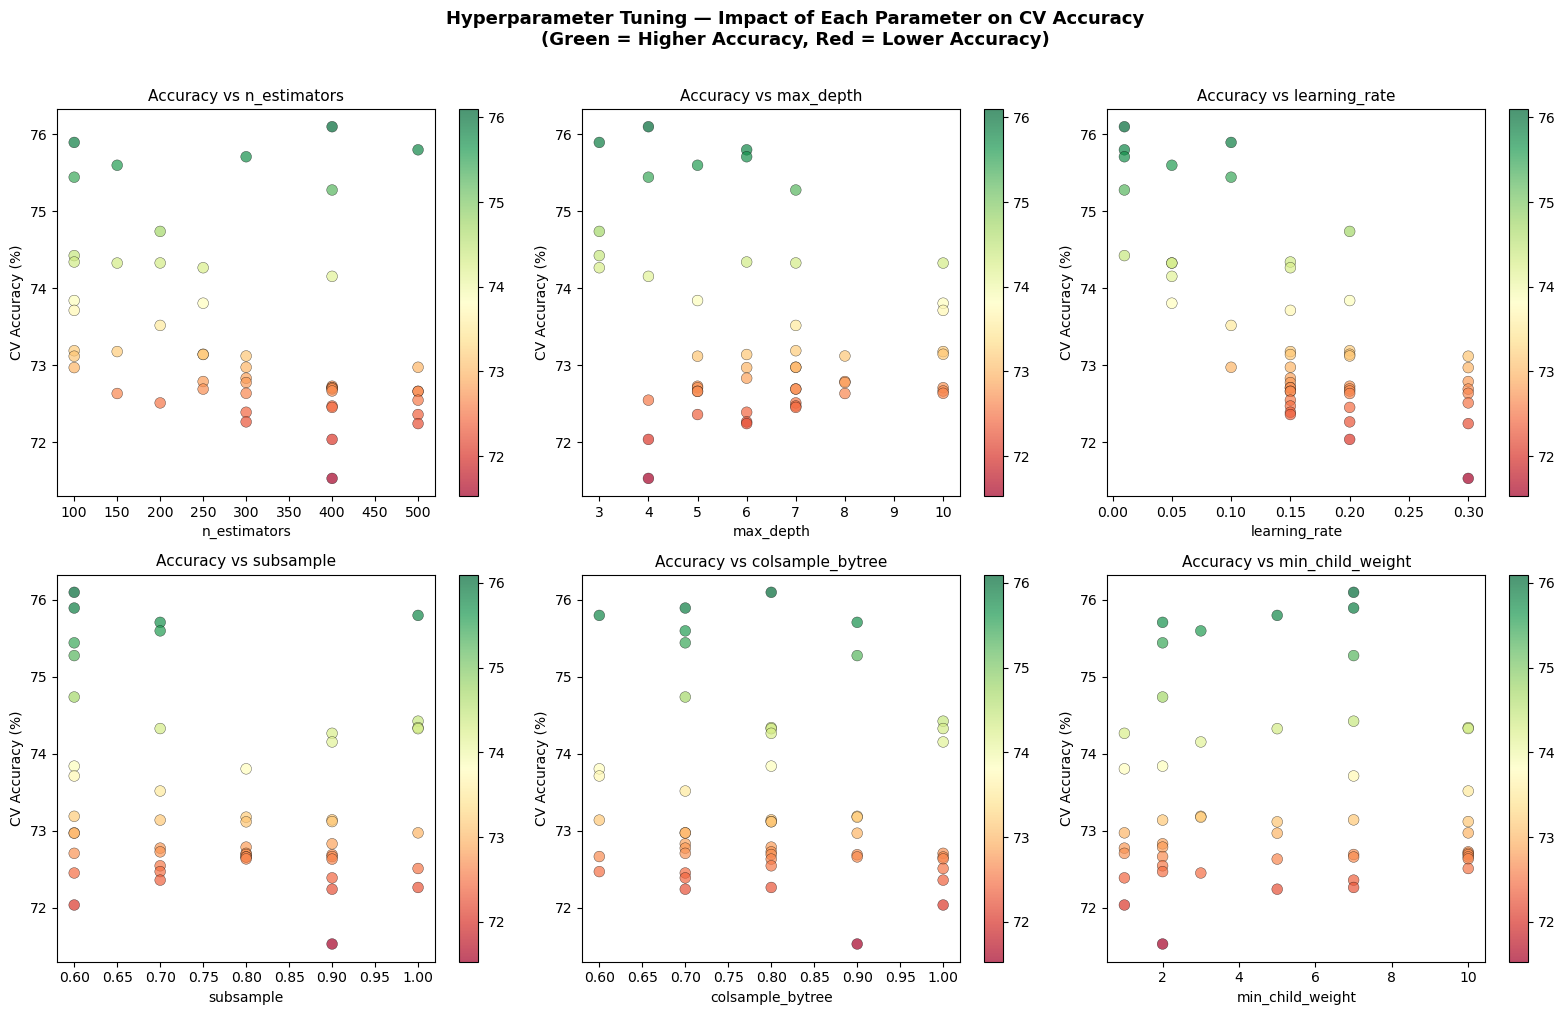

✅ Tuning visualization saved


In [9]:
# Extract CV results from the search
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values(
    'mean_test_score', ascending=False
).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Plot accuracy distribution for each key hyperparameter
key_params = [
    'param_n_estimators', 'param_max_depth', 
    'param_learning_rate', 'param_subsample',
    'param_colsample_bytree', 'param_min_child_weight'
]

for ax, param in zip(axes, key_params):
    param_name = param.replace('param_', '')
    
    scatter = ax.scatter(
        cv_results_sorted[param].astype(float),
        cv_results_sorted['mean_test_score'] * 100,
        c=cv_results_sorted['mean_test_score'] * 100,
        cmap='RdYlGn',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidth=0.3
    )
    
    ax.set_xlabel(param_name, fontsize=10)
    ax.set_ylabel('CV Accuracy (%)', fontsize=10)
    ax.set_title(f'Accuracy vs {param_name}', fontsize=11)
    plt.colorbar(scatter, ax=ax)

plt.suptitle(
    'Hyperparameter Tuning — Impact of Each Parameter on CV Accuracy\n'
    '(Green = Higher Accuracy, Red = Lower Accuracy)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../output/hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tuning visualization saved")

In [10]:
# Save the tuned model as our new production model
with open('../models/win_predictor_model.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)

# Save column names (same as before)
with open('../models/model_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# Save best params for documentation
best_params_df = pd.DataFrame([random_search.best_params_])
best_params_df.to_csv('../output/best_hyperparameters.csv', index=False)

print("✅ Tuned model saved to models/win_predictor_model.pkl")
print("✅ Column names saved to models/model_columns.pkl")
print("✅ Best parameters saved to outputs/best_hyperparameters.csv")
print(f"\nFinal model: XGBoost (tuned)")
print(f"Test accuracy: {tuned_accuracy*100:.2f}%")
print(f"Improvement over baseline: {improvement:+.2f}%")

✅ Tuned model saved to models/win_predictor_model.pkl
✅ Column names saved to models/model_columns.pkl
✅ Best parameters saved to outputs/best_hyperparameters.csv

Final model: XGBoost (tuned)
Test accuracy: 77.91%
Improvement over baseline: +0.79%
